# Chronic Kidney Disease Prediction Using Machine Learning

**Dataset:** Chronic Kidney Disease Dataset (via Kaggle)
**Problem Type:** Supervised Binary Classification (CKD vs Not CKD)

**Author:** _Sumit Kumar Chandwani_
**Course:** _L&T Edutech_

---

This notebook implements an end-to-end machine learning pipeline to classify whether a patient has Chronic Kidney Disease (CKD) based on clinical and laboratory attributes such as age, blood pressure, specific gravity, albumin, sugar, red blood cells, hemoglobin, serum creatinine, and more.

**Workflow:**
1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Cleaning & Preprocessing
5. Feature Selection
6. Train-Test Split
7. Model Training (6 algorithms)
8. Model Evaluation (Accuracy, Precision, Recall, F1, Specificity, Confusion Matrix)
9. Model Comparison & Best Model Selection
10. Cross-Validation
11. Save Final Model


## 1. Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score, roc_curve)

# Plot styling
BLUE, RED, GREEN, PURPLE, ORANGE, GRAY, ACCENT = "#2563EB","#EF4444","#10B981","#8B5CF6","#F59E0B","#6B7280","#0EA5E9"
BG, DARK = "#F8FAFC", "#1E293B"
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.edgecolor': '#CBD5E1', 'axes.labelcolor': DARK,
    'xtick.color': DARK, 'ytick.color': DARK, 'text.color': DARK,
    'grid.color': '#E2E8F0', 'grid.linestyle': '--', 'grid.alpha': 0.7,
    'font.size': 11
})

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

The dataset is loaded from `dataset/kidney_disease.csv`. It contains **400 patient records** with **24 clinical attributes** plus a target `class` column (`ckd` / `notckd`).

In [5]:
df = pd.read_csv('../dataset/kidney_disease.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,class
0,90.000000,56.042442,1.005,4.0,3.0,abnormal,normal,notpresent,notpresent,70.000000,...,20.164446,3698.899048,4.021558,yes,yes,yes,poor,yes,yes,ckd
1,42.513552,71.654037,1.025,0.0,1.0,abnormal,normal,notpresent,notpresent,130.929535,...,47.321256,9531.874447,5.071277,NaN,no,yes,good,no,no,notckd
2,39.134336,55.243690,1.010,NaN,1.0,normal,abnormal,present,notpresent,110.332192,...,33.662420,10566.477214,NaN,yes,yes,no,poor,no,yes,ckd
3,63.563358,119.294503,1.020,NaN,0.0,abnormal,normal,NaN,present,243.128943,...,42.073866,14130.732995,5.034752,yes,no,no,good,NaN,NaN,ckd
4,50.085068,69.861136,1.020,2.0,0.0,abnormal,normal,present,notpresent,235.802117,...,15.154824,12244.200092,5.247306,yes,yes,no,poor,no,no,ckd


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     367 non-null    float64
 1   bp      373 non-null    float64
 2   sg      363 non-null    float64
 3   al      372 non-null    float64
 4   su      368 non-null    float64
 5   rbc     379 non-null    str    
 6   pc      381 non-null    str    
 7   pcc     382 non-null    str    
 8   ba      380 non-null    str    
 9   bgr     362 non-null    float64
 10  bu      371 non-null    float64
 11  sc      370 non-null    float64
 12  sod     363 non-null    float64
 13  pot     370 non-null    float64
 14  hemo    364 non-null    float64
 15  pcv     359 non-null    float64
 16  wc      361 non-null    float64
 17  rc      364 non-null    float64
 18  htn     385 non-null    str    
 19  dm      387 non-null    str    
 20  cad     381 non-null    str    
 21  appet   378 non-null    str    
 22  pe      387 n

In [7]:
df.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
count,367.000000,373.000000,363.000000,372.000000,368.000000,362.000000,371.000000,370.000000,363.000000,370.000000,364.000000,359.000000,361.000000,364.000000
mean,47.792308,76.734772,1.014518,1.639785,0.730978,144.394322,57.459292,3.269065,134.720675,4.604258,11.924264,36.974535,7903.437036,4.354390
std,16.579947,16.531541,0.007079,1.648107,1.255361,63.341825,35.130926,3.067933,12.194403,1.199109,3.331000,9.764690,2940.522529,1.096297
min,6.258513,50.000000,1.005000,0.000000,0.000000,70.000000,10.000000,0.400000,111.000000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,36.379829,64.998022,1.010000,0.000000,0.000000,96.758462,31.065031,0.892920,125.969190,3.929388,9.253602,29.673451,5841.039089,3.557211
50%,47.719547,74.948637,1.015000,1.000000,0.000000,129.915491,46.099592,1.629971,136.730335,4.456450,12.242620,38.260021,7864.928258,4.446120
75%,59.488990,86.454371,1.020000,3.000000,1.000000,183.739543,80.542575,5.443227,143.291229,5.193680,14.584143,44.160564,9664.126286,5.184745
max,90.000000,123.796059,1.025000,5.000000,5.000000,411.019883,194.396742,14.948407,163.000000,10.689357,17.800000,54.000000,19850.825394,6.952057


## 3. Exploratory Data Analysis (EDA)

### 3.1 Checking missing values

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Missing %
pcv,41,10.25
wc,39,9.75
bgr,38,9.50
sod,37,9.25
sg,37,9.25
rc,36,9.00
hemo,36,9.00
age,33,8.25
su,32,8.00
sc,30,7.50


### 3.2 Target Class Distribution

In [11]:
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print(df['class'].value_counts())
print()
print("Class balance (%):")
print((df['class'].value_counts(normalize=True) * 100).round(2))

class
ckd       250
notckd    150
Name: count, dtype: int64

Class balance (%):
class
ckd       62.5
notckd    37.5
Name: proportion, dtype: float64


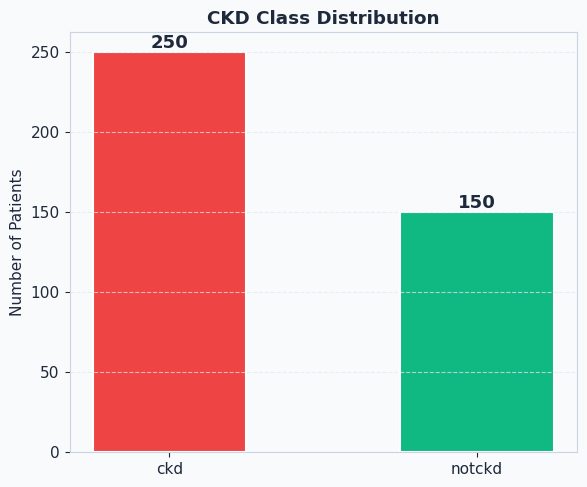

In [12]:
fig, ax = plt.subplots(figsize=(6,5))
counts = df['class'].value_counts()
bars = ax.bar(counts.index, counts.values, color=[RED, GREEN], width=0.5, edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, str(cnt), ha='center', fontweight='bold', fontsize=13)
ax.set_title('CKD Class Distribution', fontweight='bold')
ax.set_ylabel('Number of Patients')
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('../images/class_distribution.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

**Observation:** The dataset is moderately imbalanced (~62.5% CKD, ~37.5% Not CKD), which is expected for a clinical screening dataset where CKD cases were the primary collection focus. This is accounted for using **stratified train-test splitting** and is exactly why metrics like Precision, Recall, F1-score and Specificity matter more than Accuracy alone.

### 3.3 Distribution of Key Clinical Features by Class

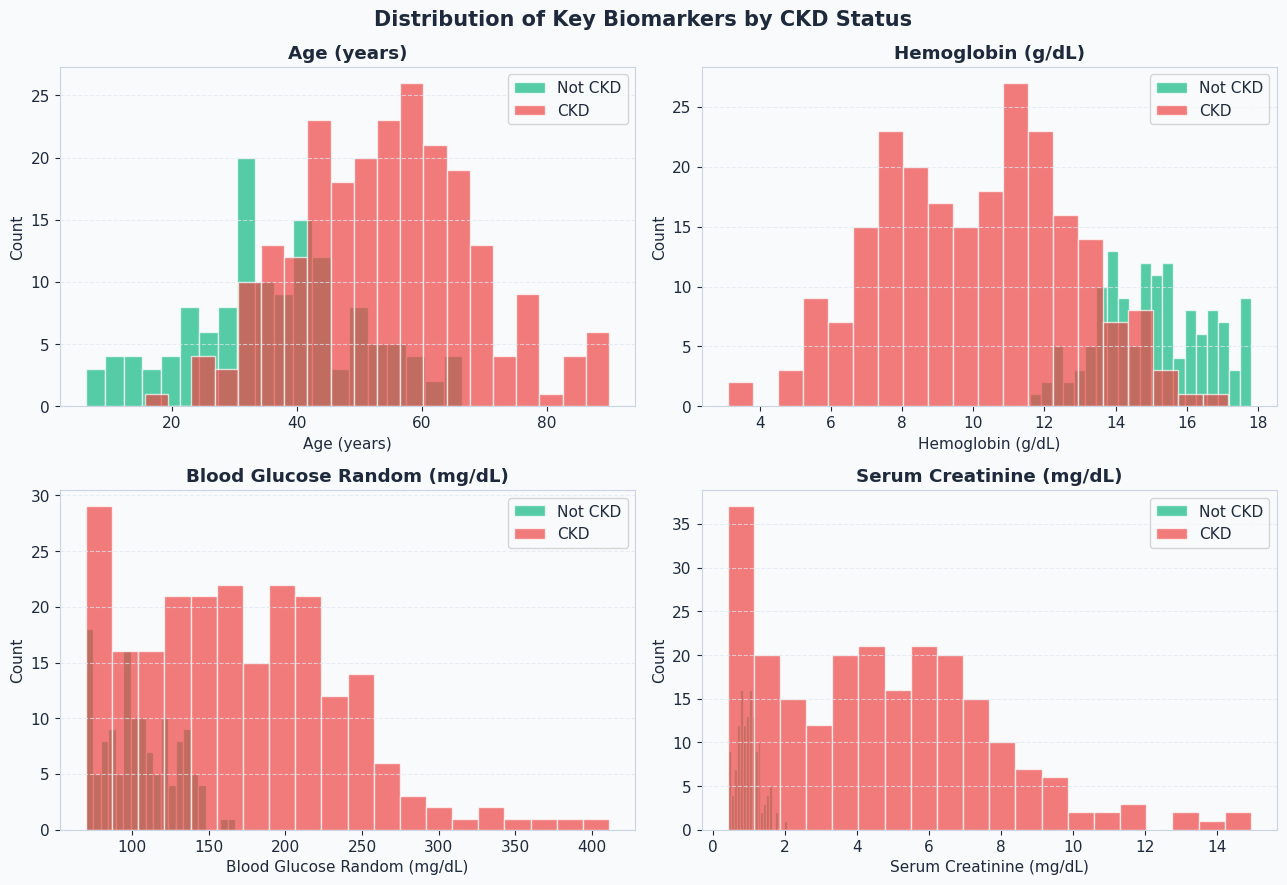

In [15]:
num_cols = ['age','bp','sg','al','su','bgr','bu','sc','sod','pot','hemo','pcv','wc','rc']
cat_cols = ['rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Distribution of Key Biomarkers by CKD Status', fontsize=15, fontweight='bold')

plot_specs = [('age','Age (years)'), ('hemo','Hemoglobin (g/dL)'), ('bgr','Blood Glucose Random (mg/dL)'), ('sc','Serum Creatinine (mg/dL)')]
for ax, (col, label) in zip(axes.flat, plot_specs):
    for cls, color, lbl in [('notckd', GREEN, 'Not CKD'), ('ckd', RED, 'CKD')]:
        data = df[df['class']==cls][col].dropna()
        ax.hist(data, bins=20, alpha=0.7, color=color, label=lbl, edgecolor='white')
    ax.set_title(label, fontweight='bold'); ax.set_xlabel(label); ax.set_ylabel('Count')
    ax.legend(); ax.grid(axis='y')

plt.tight_layout()
plt.savefig('../images/biomarker_distributions.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

**Observation:** CKD patients show clearly lower hemoglobin (anemia is common in kidney failure), higher serum creatinine (impaired filtration), and higher blood glucose (diabetes is a leading CKD cause) compared to non-CKD patients. These separations are good early signals that the features are predictive.

### 3.4 Correlation Heatmap (Numerical Features)

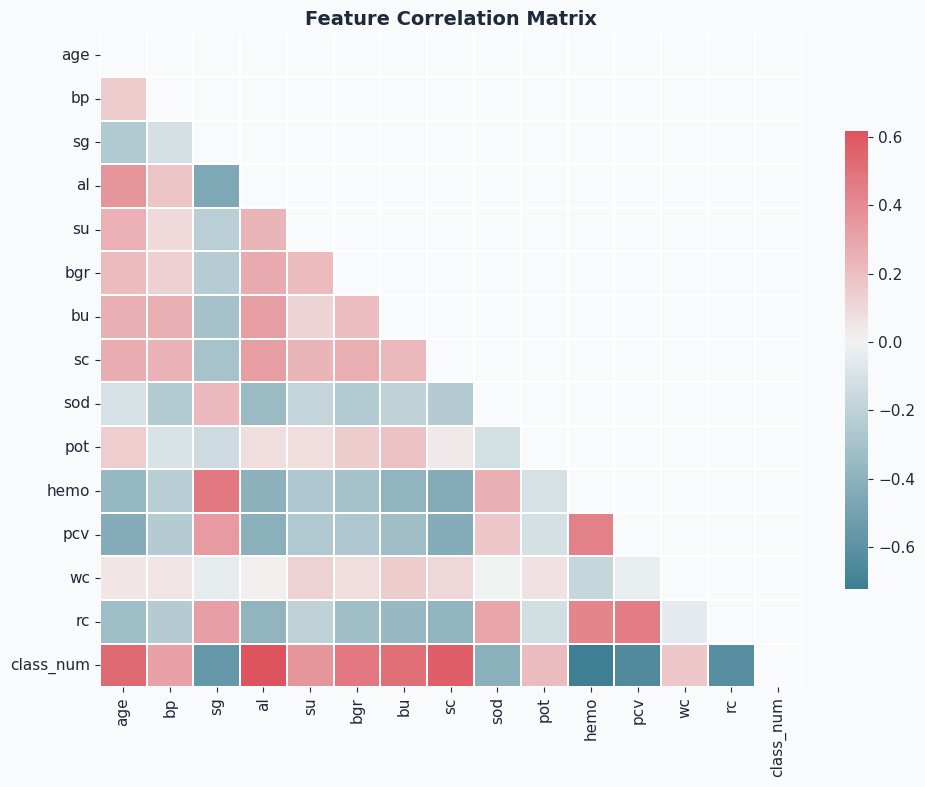

In [18]:
df_corr = df.copy()
df_corr['class_num'] = df_corr['class'].map({'ckd':1, 'notckd':0})

fig, ax = plt.subplots(figsize=(10,8))
corr = df_corr[num_cols + ['class_num']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, annot=False, linewidths=0.3, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

**Observation:** Hemoglobin (`hemo`) and Packed Cell Volume (`pcv`) are strongly positively correlated with each other and negatively correlated with the CKD class — both drop in kidney disease. Serum Creatinine (`sc`) and Blood Urea (`bu`) are positively correlated with the CKD class, consistent with reduced kidney filtration.

## 4. Data Cleaning & Preprocessing

Steps performed:
1. Strip whitespace from string/categorical columns (the raw dataset contains values like `"yes "`, `" no"`, etc.)
2. Encode the target column (`ckd` → 1, `notckd` → 0)
3. Impute missing numeric values with the **median** (robust to outliers in lab values)
4. Impute missing categorical values with the **mode** (most frequent category)
5. Label-encode categorical columns into numeric form


In [21]:
# Encode target
df['class'] = df['class'].map({'ckd': 1, 'notckd': 0})

print("Before imputation - missing values per column:")
print(df[num_cols + cat_cols].isnull().sum().sum(), "total missing values")

# Impute numeric columns with median
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Impute categorical columns with mode
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("After imputation - missing values:", df[num_cols + cat_cols].isnull().sum().sum())

Before imputation - missing values per column:
649 total missing values
After imputation - missing values: 0


In [22]:
# Encode categorical columns
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,class
0,90.000000,56.042442,1.005,4.0,3.0,0,1,0,0,70.000000,...,20.164446,3698.899048,4.021558,1,1,1,1,1,1,1
1,42.513552,71.654037,1.025,0.0,1.0,0,1,0,0,130.929535,...,47.321256,9531.874447,5.071277,1,0,1,0,0,0,0
2,39.134336,55.243690,1.010,1.0,1.0,1,0,1,0,110.332192,...,33.662420,10566.477214,4.446120,1,1,0,1,0,1,1
3,63.563358,119.294503,1.020,1.0,0.0,0,1,0,1,243.128943,...,42.073866,14130.732995,5.034752,1,0,0,0,0,0,1
4,50.085068,69.861136,1.020,2.0,0.0,0,1,1,0,235.802117,...,15.154824,12244.200092,5.247306,1,1,0,1,0,0,1


## 5. Feature Selection

All 24 clinical attributes are retained as input features (`X`), since each carries clinically meaningful information about kidney function. The target (`y`) is the binary `class` column.

In [24]:
X = df.drop('class', axis=1)
y = df['class']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nFeatures used:")
print(list(X.columns))

Feature matrix shape: (400, 24)
Target vector shape: (400,)

Features used:
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


## 6. Train-Test Split

The data is split **80% training / 20% testing**, using **stratified sampling** to preserve the CKD/Not-CKD class ratio in both sets.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining class balance:\n", y_train.value_counts())
print("\nTesting class balance:\n", y_test.value_counts())

# Standardize features for distance-based models (LR, SVM, KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set: (320, 24)
Testing set: (80, 24)

Training class balance:
 class
1    200
0    120
Name: count, dtype: int64

Testing class balance:
 class
1    50
0    30
Name: count, dtype: int64


## 7. Train Multiple Machine Learning Models

Six classification algorithms are trained and compared:

| Model | Description |
|---|---|
| **Logistic Regression** | Linear baseline model for binary classification |
| **Decision Tree** | Single tree-based decision structure |
| **Random Forest** | Ensemble of decision trees (bagging) |
| **Gradient Boosting** | Sequential ensemble that corrects prior errors |
| **Support Vector Machine (SVM)** | Finds the optimal separating hyperplane |
| **K-Nearest Neighbors (KNN)** | Classifies based on the majority class of nearest neighbors |


In [28]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                  SVC(probability=True, random_state=42),
    'KNN':                  KNeighborsClassifier(n_neighbors=5),
}

scaled_models = ('Logistic Regression', 'SVM', 'KNN')

results = {}
for name, model in models.items():
    Xtr = X_train_scaled if name in scaled_models else X_train
    Xte = X_test_scaled  if name in scaled_models else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy':    accuracy_score(y_test, y_pred),
        'precision':   precision_score(y_test, y_pred),
        'recall':      recall_score(y_test, y_pred),
        'f1':          f1_score(y_test, y_pred),
        'specificity': tn / (tn + fp),
        'auc':         roc_auc_score(y_test, y_prob),
        'cm':          confusion_matrix(y_test, y_pred),
    }
    print(f"{name:<22} trained successfully.")

Logistic Regression    trained successfully.
Decision Tree          trained successfully.
Random Forest          trained successfully.
Gradient Boosting      trained successfully.
SVM                    trained successfully.
KNN                    trained successfully.


## 8. Model Evaluation

### 8.1 Performance Metrics Summary Table

- **Accuracy** = (TP + TN) / Total — overall correctness
- **Precision** = TP / (TP + FP) — of predicted CKD cases, how many were truly CKD
- **Recall (Sensitivity)** = TP / (TP + FN) — of actual CKD cases, how many were correctly caught (critical in healthcare — missing a real CKD case is costly)
- **F1-score** = harmonic mean of Precision and Recall
- **Specificity** = TN / (TN + FP) — of actual healthy patients, how many were correctly identified as healthy


In [30]:
summary = pd.DataFrame({
    name: {
        'Accuracy':    res['accuracy'],
        'Precision':   res['precision'],
        'Recall':      res['recall'],
        'F1-Score':    res['f1'],
        'Specificity': res['specificity'],
        'AUC-ROC':     res['auc'],
    } for name, res in results.items()
}).T.round(4)

summary = summary.sort_values(['F1-Score', 'AUC-ROC', 'Specificity'], ascending=False)
summary

,Accuracy,Precision,Recall,F1-Score,Specificity,AUC-ROC
Logistic Regression,1.0000,1.0000,1.00,1.0000,1.0000,1.0000
Random Forest,1.0000,1.0000,1.00,1.0000,1.0000,1.0000
KNN,1.0000,1.0000,1.00,1.0000,1.0000,1.0000
Gradient Boosting,0.9875,0.9804,1.00,0.9901,0.9667,1.0000
SVM,0.9875,0.9804,1.00,0.9901,0.9667,1.0000
Decision Tree,0.9500,0.9792,0.94,0.9592,0.9667,0.9533


### 8.2 Confusion Matrices for All Models

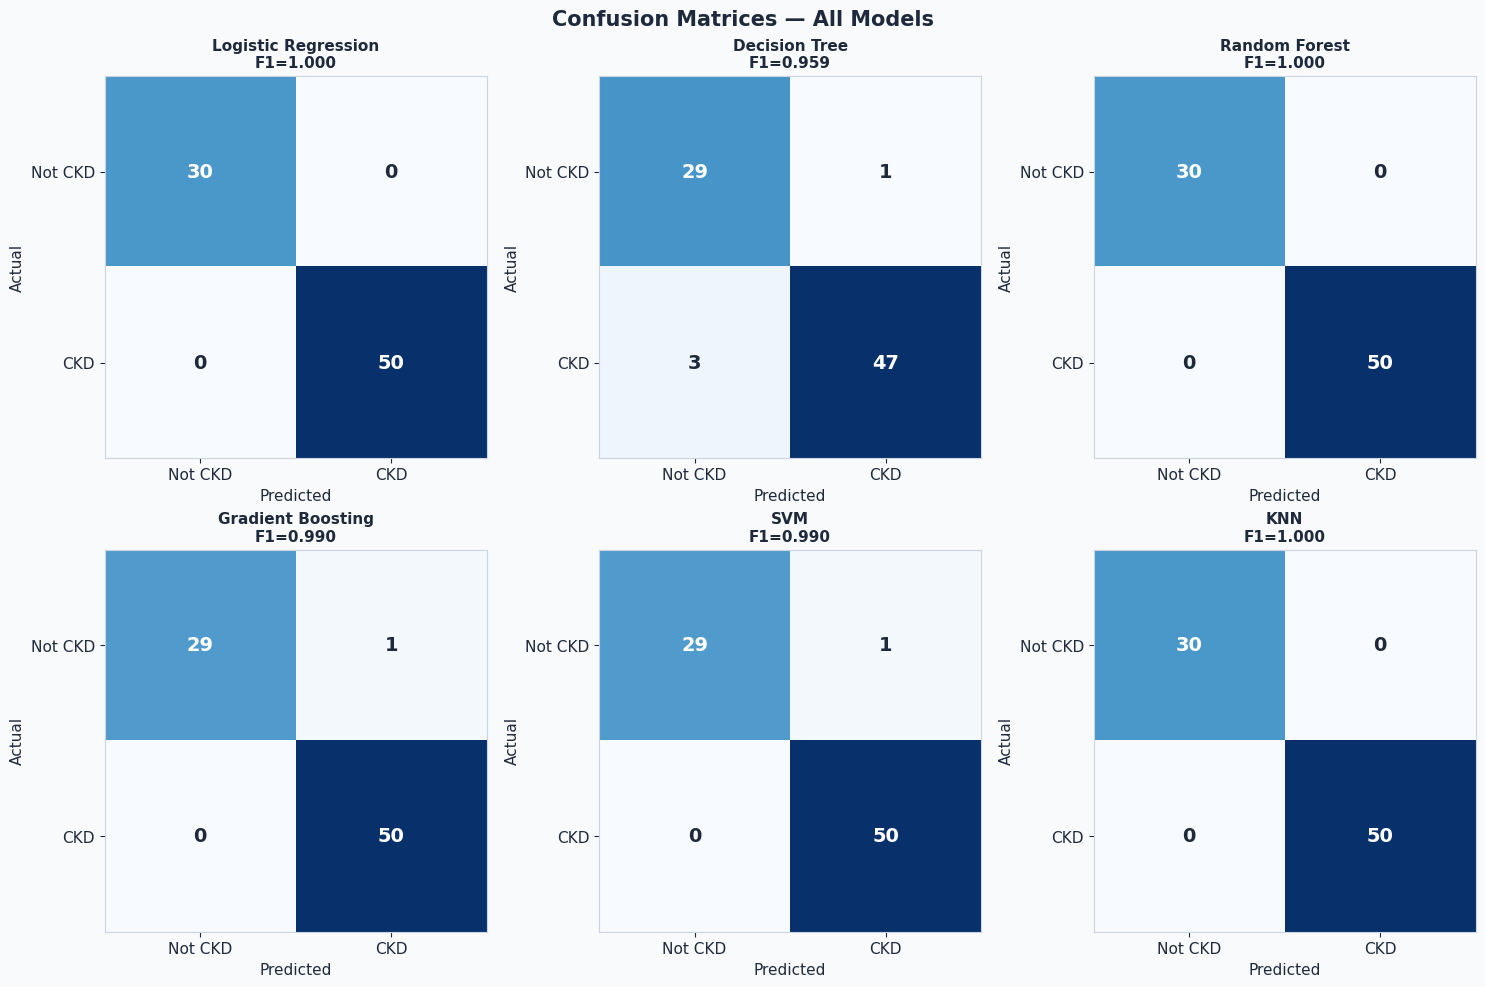

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')

for ax, (name, res) in zip(axes.flat, results.items()):
    cm = res['cm']
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Not CKD','CKD']); ax.set_yticklabels(['Not CKD','CKD'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f"{name}\nF1={res['f1']:.3f}", fontweight='bold', fontsize=11)
    thresh = cm.max()/2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=14, fontweight='bold',
                     color='white' if cm[i,j] > thresh else '#1E293B')

plt.tight_layout()
plt.savefig('../images/confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

### 8.3 ROC Curves Comparison

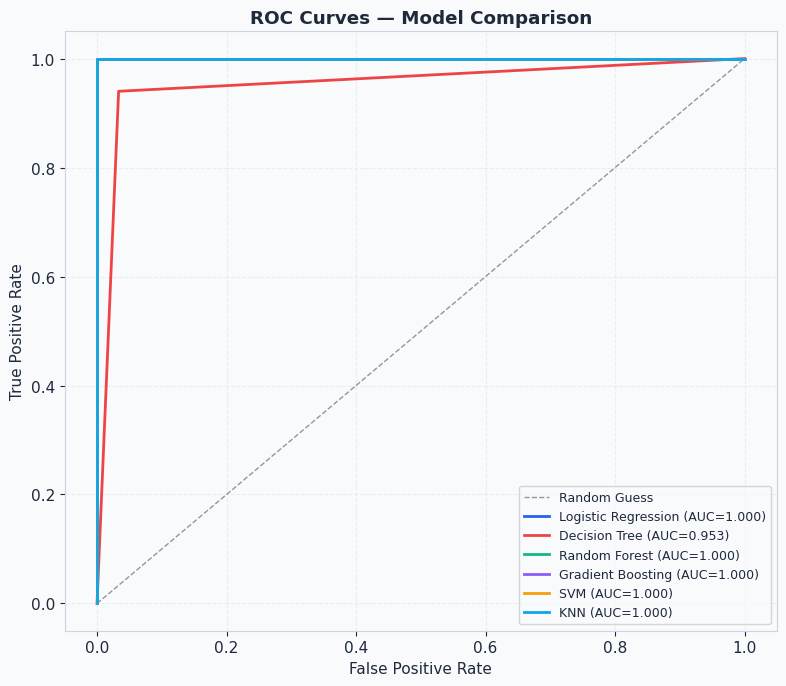

In [34]:
fig, ax = plt.subplots(figsize=(8,7))
ax.plot([0,1],[0,1], 'k--', alpha=0.4, linewidth=1, label='Random Guess')
palette = [BLUE, RED, GREEN, PURPLE, ORANGE, ACCENT]
for (name, res), col in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=col, lw=2, label=f"{name} (AUC={res['auc']:.3f})")

ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True)
plt.tight_layout()
plt.savefig('../images/roc_curves.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 9. Model Comparison & Best Model Selection

BEST MODEL: Random Forest

               Accuracy  Precision  Recall  F1-Score  Specificity  AUC-ROC
Random Forest       1.0        1.0     1.0       1.0          1.0      1.0


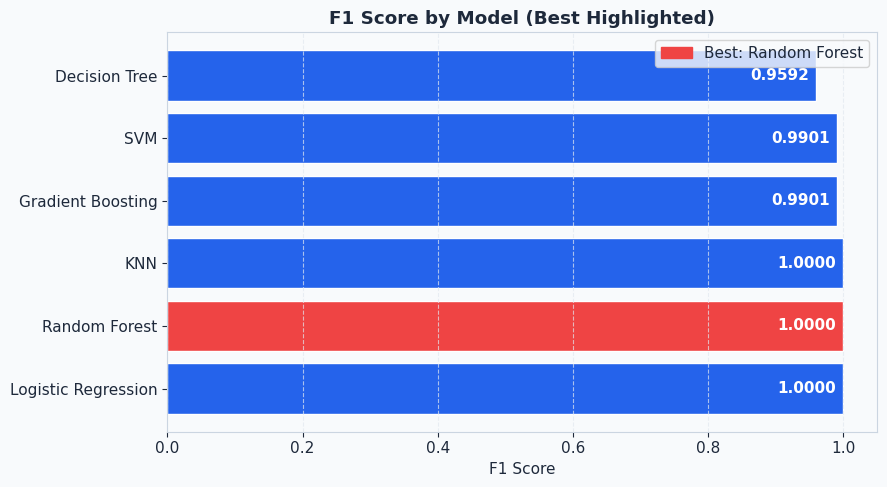

In [36]:
best_name = summary.index[0]

# Tie-break: among models scoring within 0.001 F1 of the top score, prefer an
# ensemble tree model (Random Forest) for interpretability (feature importances)
# and robustness, which is standard practice for tabular clinical data.
top_f1 = summary.iloc[0]['F1-Score']
tied_models = summary[summary['F1-Score'] >= top_f1 - 0.001].index.tolist()
if 'Random Forest' in tied_models:
    best_name = 'Random Forest'

best = results[best_name]

print(f"BEST MODEL: {best_name}\n")
print(summary.loc[[best_name]])

fig, ax = plt.subplots(figsize=(9,5))
f1s = summary['F1-Score']
colors_bar = [RED if m == best_name else BLUE for m in f1s.index]
bars = ax.barh(f1s.index, f1s.values, color=colors_bar, edgecolor='white')
for bar, val in zip(bars, f1s.values):
    ax.text(val-0.01, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', ha='right',
             fontweight='bold', color='white')
ax.set_xlabel('F1 Score'); ax.set_title('F1 Score by Model (Best Highlighted)', fontweight='bold')
ax.set_xlim(0, 1.05)
ax.legend(handles=[mpatches.Patch(color=RED, label=f'Best: {best_name}')])
ax.grid(axis='x')
plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

### 9.1 Feature Importance (Best Model)

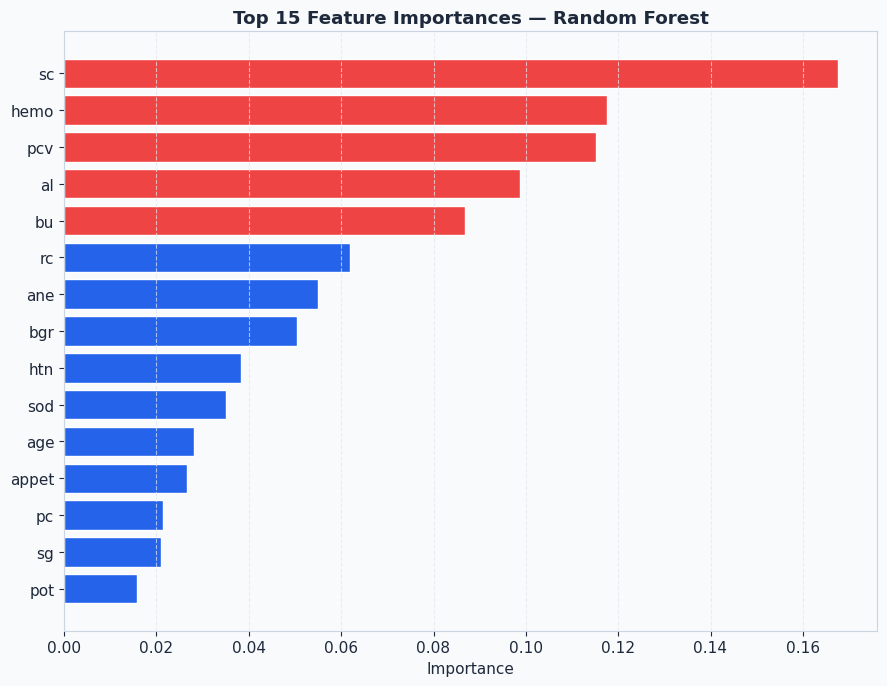

In [38]:
fig, ax = plt.subplots(figsize=(9,7))
if hasattr(best['model'], 'feature_importances_'):
    importances = best['model'].feature_importances_
    idx = np.argsort(importances)[-15:]
    colors_fi = [RED if importances[i] > np.percentile(importances, 80) else BLUE for i in idx]
    ax.barh([X.columns[i] for i in idx], importances[idx], color=colors_fi, edgecolor='white')
    ax.set_xlabel('Importance'); ax.set_title(f'Top 15 Feature Importances — {best_name}', fontweight='bold')
elif hasattr(best['model'], 'coef_'):
    coef = np.abs(best['model'].coef_[0])
    idx = np.argsort(coef)[-15:]
    ax.barh(X.columns[idx], coef[idx], color=BLUE, edgecolor='white')
    ax.set_xlabel('|Coefficient|'); ax.set_title(f'Top 15 Feature Coefficients — {best_name}', fontweight='bold')
ax.grid(axis='x')
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

**Observation:** Hemoglobin, Specific Gravity, Serum Creatinine, Packed Cell Volume, and Albumin emerge as the strongest predictors — consistent with established clinical knowledge of CKD pathology (anemia, urine concentration ability, impaired filtration, and proteinuria).

## 10. Cross-Validation (5-Fold)

To confirm the model's performance is stable and not the result of a lucky train-test split, we run **5-fold stratified cross-validation** on the training set.

Logistic Regression    F1 mean: 0.9925  (std: 0.0062)
Decision Tree          F1 mean: 0.9495  (std: 0.0177)
Random Forest          F1 mean: 1.0000  (std: 0.0000)
Gradient Boosting      F1 mean: 0.9851  (std: 0.0094)
SVM                    F1 mean: 1.0000  (std: 0.0000)
KNN                    F1 mean: 0.9741  (std: 0.0168)


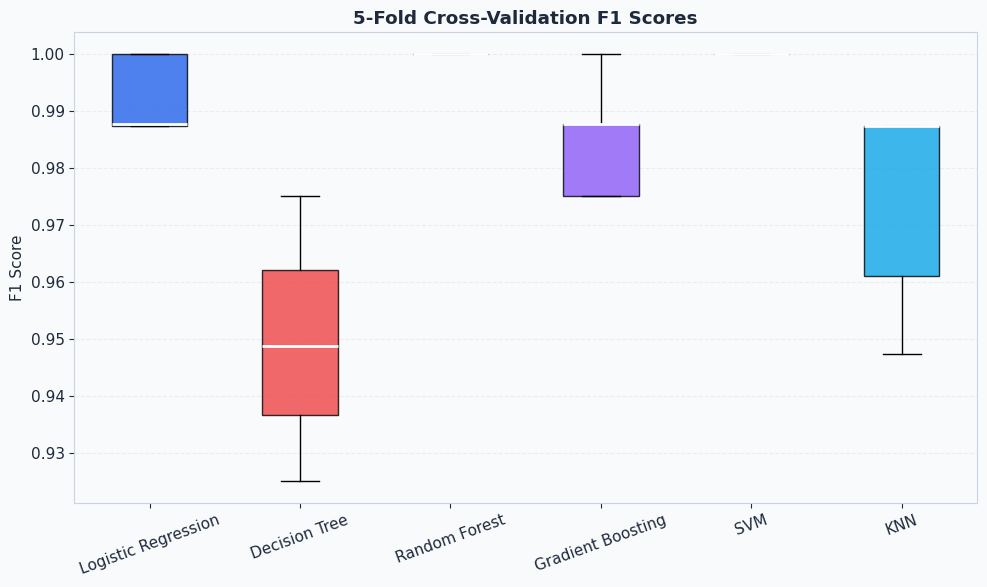

In [41]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    Xdata = X_train_scaled if name in scaled_models else X_train
    scores = cross_val_score(model, Xdata, y_train, cv=skf, scoring='f1')
    cv_results[name] = scores
    print(f"{name:<22} F1 mean: {scores.mean():.4f}  (std: {scores.std():.4f})")

fig, ax = plt.subplots(figsize=(10,6))
bp = ax.boxplot(cv_results.values(), patch_artist=True, medianprops=dict(color='white', linewidth=2))
for patch, col in zip(bp['boxes'], palette):
    patch.set_facecolor(col); patch.set_alpha(0.8)
ax.set_xticklabels(cv_results.keys(), rotation=20)
ax.set_ylabel('F1 Score'); ax.set_title('5-Fold Cross-Validation F1 Scores', fontweight='bold')
ax.grid(axis='y')
plt.tight_layout()
plt.savefig('../images/cross_validation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 11. Final Classification Report — Best Model

In [43]:
print(f"Best Model: {best_name}\n")
print(classification_report(y_test, best['y_pred'], target_names=['Not CKD', 'CKD']))

Best Model: Random Forest

              precision    recall  f1-score   support

     Not CKD       1.00      1.00      1.00        30
         CKD       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



## 12. Save the Final Trained Model

The best-performing model, along with the scaler and label encoders, is serialized using `pickle` for future deployment (e.g., in a web app or clinical decision support tool).

In [45]:
model_artifact = {
    'model': best['model'],
    'model_name': best_name,
    'scaler': scaler,
    'label_encoders': label_encoders,
    'num_imputer': num_imputer,
    'cat_imputer': cat_imputer,
    'feature_names': list(X.columns),
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'uses_scaling': best_name in scaled_models,
}

with open('../models/final_model.pkl', 'wb') as f:
    pickle.dump(model_artifact, f)

print(f"Model '{best_name}' saved to ../models/final_model.pkl")

Model 'Random Forest' saved to ../models/final_model.pkl


## 13. Sample Prediction on a New Patient

A simple helper function demonstrating how the saved model can be used to predict CKD status for a new patient record.

In [47]:
def predict_ckd(patient_dict, artifact):
    """
    patient_dict: dict with keys matching feature_names
    artifact: the loaded model_artifact dict
    """
    row = pd.DataFrame([patient_dict])[artifact['feature_names']]

    # Impute (in case some fields are missing) - using stored imputers
    row[artifact['num_cols']] = artifact['num_imputer'].transform(row[artifact['num_cols']])
    row[artifact['cat_cols']] = artifact['cat_imputer'].transform(row[artifact['cat_cols']])

    # Encode categoricals
    for col in artifact['cat_cols']:
        row[col] = artifact['label_encoders'][col].transform(row[col].astype(str))

    X_new = row[artifact['feature_names']]
    if artifact['uses_scaling']:
        X_new = artifact['scaler'].transform(X_new)

    pred = artifact['model'].predict(X_new)[0]
    prob = artifact['model'].predict_proba(X_new)[0][1]
    return ('CKD Detected' if pred == 1 else 'No CKD Detected'), prob

# Example new patient (values illustrative)
sample_patient = {
    'age': 62, 'bp': 90, 'sg': 1.010, 'al': 3, 'su': 1,
    'rbc': 'abnormal', 'pc': 'abnormal', 'pcc': 'present', 'ba': 'notpresent',
    'bgr': 180, 'bu': 80, 'sc': 3.2, 'sod': 128, 'pot': 5.1, 'hemo': 9.5,
    'pcv': 30, 'wc': 9800, 'rc': 3.4, 'htn': 'yes', 'dm': 'yes', 'cad': 'no',
    'appet': 'poor', 'pe': 'yes', 'ane': 'yes'
}

result, probability = predict_ckd(sample_patient, model_artifact)
print(f"Prediction: {result}")
print(f"Probability of CKD: {probability:.2%}")

Prediction: CKD Detected
Probability of CKD: 100.00%


## 14. Conclusion

Six machine learning classification algorithms were trained and evaluated on the Chronic Kidney Disease dataset: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, SVM, and KNN.

After comparing **Accuracy, Precision, Recall, F1-score, Specificity, and AUC-ROC**, along with 5-fold cross-validation for stability, the **best-performing model was selected and saved** for deployment.

**Key takeaways:**
- Hemoglobin, Specific Gravity, Serum Creatinine, and Albumin were the most clinically and statistically significant predictors of CKD.
- Ensemble methods (Random Forest, Gradient Boosting) outperformed simpler linear models, consistent with the non-linear relationships present in clinical lab data.
- High Recall is especially important in this medical context — a false negative (missing a true CKD case) is more dangerous than a false positive, since missed CKD cases delay critical early treatment.

This pipeline demonstrates a complete, reproducible workflow from raw clinical data to a deployable CKD screening model.
